# **Experiment Notebook 2**



In [1]:
# Do not modify this code
%pip install -q utstd

from utstd.ipyrenders import *

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [3]:
import os, json, math, pathlib, warnings
from datetime import date
from collections import Counter
from pathlib import Path
from dataclasses import dataclass
from typing import Dict
from joblib import dump

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.inspection import permutation_importance

from amla_at1.data.openmeteo import fetch_daily_archive, make_supervised_tables
from amla_at1.data.time_split import split_by_date
from amla_at1.features.weather import clip_and_fill, normalize_cols
from amla_at1.models.export import save_model

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)

# Project paths

ROOT = Path.cwd().resolve()
DATA_DIR = (ROOT / "../precipitation_fall/data").resolve()
RAW_DIR = DATA_DIR / "raw"
PROC_DIR = DATA_DIR / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR.mkdir(parents=True, exist_ok=True)

@dataclass
class _Artifacts:
    folder_path: Path = PROC_DIR
at = _Artifacts()

---
## A. Project Description


In [4]:
# <Student to fill this section>
student_name = "Nayna Jahan Neha"
student_id = "25238736"

In [5]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [6]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## B. Business Understanding

In [7]:
# <Student to fill this section>
business_use_case_description = """
The goal is to provide an API that predicts the total precipitation (rain + snow) expected over the next 3 days in Sydney (mm), with calibrated estimates and error diagnostics, so operations (events, construction, logistics) can plan crews, tarping/drainage, delivery windows, and safety measures.
Hypothesis: Recent weather regime (14-day rolling signals) plus seasonality can forecast 3-day precipitation amounts better than climatology, reducing weather-related costs (delays, damage, cancellations) and improving on-time execution.
"""

In [8]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [9]:
# <Student to fill this section>
business_objectives = """
The objective of the project is to get accurate results with allocation of crews/equipment, timely venue or schedule changes, reduced damage and overtime, higher on-time delivery and safety. Probabilistic/interval outputs let clients set thresholds by cost/risk.

Incorrect results can have consequences, such as, Overestimation → unnecessary prep/rescheduling, higher costs, potential alarm fatigue and Underestimation → flood/water damage, missed deadlines, safety incidents, refunds.
We therefore target lower RMSE/MAE on amounts and monitor tail errors; when confidence is low, we surface uncertainty and conservative alerts.
"""

In [10]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [11]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
The exposed results can be used via API and dashboards showing predicted 3-day precipitation (mm), confidence/intervals, and alerts. Integrated into weekly/daily planning, scheduling, and automated playbooks (tarping, drainage, rerouting). Users include operations planners, site/venue managers, dispatch/logistics coordinators, and product teams embedding the API. The prediction results will be impacting the data driven decisions of field crews and contractors (rosters/safety), transport/inventory (routing, stock), finance (costs/penalties), end customers/attendees (service quality), and compliance/safety teams (risk reduction). Expectations for the project include reliable uptime, stable schema, calibrated forecasts, documented thresholds, and drift monitoring.
"""

In [12]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets


In [13]:
CACHE = pathlib.Path("data/raw/sydney_daily_2015_2024.csv")
CACHE.parent.mkdir(parents=True, exist_ok=True)

if CACHE.exists():
    daily = pd.read_csv(CACHE, parse_dates=["date"])
    daily["date"] = daily["date"].dt.date
    daily = daily.set_index("date").sort_index()
else:
    daily = fetch_daily_archive(
        start_date="2015-01-01",
        end_date="2024-12-31",
        timezone="Australia/Sydney"
    )
    daily.to_csv(CACHE, index=True)

daily.head(5)

,weather_code,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,rain_sum,snowfall_sum,precipitation_hours,sunshine_duration,daylight_duration,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,shortwave_radiation_sum,et0_fao_evapotranspiration
date,,,,,,,,,,,,,,,,
2015-01-01,3,27.0,20.2,31.8,22.2,0.0,0.0,0.0,0.0,48474.35,51701.08,17.3,37.4,59,29.62,5.48
2015-01-02,3,26.7,21.0,30.6,22.5,0.0,0.0,0.0,0.0,24758.28,51668.00,16.0,34.6,140,20.24,3.91
2015-01-03,3,27.4,21.5,32.4,25.4,0.0,0.0,0.0,0.0,44821.78,51631.56,21.1,45.4,52,28.44,5.30
2015-01-04,63,29.2,21.0,35.4,22.2,10.2,10.2,0.0,5.0,41183.68,51591.87,21.9,46.8,95,26.66,5.37
2015-01-05,51,23.6,20.6,25.6,21.3,0.5,0.5,0.0,4.0,8040.91,51549.03,16.8,32.0,150,10.44,2.37


### C.2 Define Target variable

In [14]:
# For precipitation_fall: regression target = sum of precipitation next 3 days (D+1..D+3)

X_cls, y_cls, X_reg, y_reg = make_supervised_tables(
    daily_df=daily,
    rain_label_lag_days=7,    
    precip_window_days=3,
    feature_lookback_days=14,
)

df_reg = pd.concat([X_reg, y_reg.rename("precip_next3_sum")], axis=1).dropna()
df_reg.head(3)

,temperature_2m_max_mean_14,temperature_2m_max_std_14,temperature_2m_max_sum_14,temperature_2m_min_mean_14,temperature_2m_min_std_14,temperature_2m_min_sum_14,apparent_temperature_max_mean_14,apparent_temperature_max_std_14,apparent_temperature_max_sum_14,apparent_temperature_min_mean_14,apparent_temperature_min_std_14,apparent_temperature_min_sum_14,precipitation_sum_mean_14,precipitation_sum_std_14,precipitation_sum_sum_14,rain_sum_mean_14,rain_sum_std_14,rain_sum_sum_14,wind_speed_10m_max_mean_14,wind_speed_10m_max_std_14,wind_speed_10m_max_sum_14,wind_gusts_10m_max_mean_14,wind_gusts_10m_max_std_14,wind_gusts_10m_max_sum_14,shortwave_radiation_sum_mean_14,shortwave_radiation_sum_std_14,shortwave_radiation_sum_sum_14,et0_fao_evapotranspiration_mean_14,et0_fao_evapotranspiration_std_14,et0_fao_evapotranspiration_sum_14,sunshine_duration_mean_14,sunshine_duration_std_14,sunshine_duration_sum_14,month,dayofyear,is_summer,precip_next3_sum
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-03,27.033333,0.351188,81.1,20.900,0.655744,62.7,31.60,0.916515,94.8,23.366667,1.767295,70.1,0.00,0.000000,0.0,0.00,0.000000,0.0,18.133333,2.650157,54.4,39.133333,5.604760,117.4,26.10,5.109090,78.30,4.896667,0.859205,14.69,39351.4700,12769.346604,118054.41,1,3,1,10.2
2015-01-04,27.575000,1.120640,110.3,20.925,0.537742,83.7,32.55,2.042058,130.2,23.075000,1.556438,92.3,2.55,5.100000,10.2,2.55,5.100000,10.2,19.075000,2.868652,76.3,41.050000,5.969645,164.2,26.24,4.180941,104.96,5.015000,0.740383,20.06,39809.5225,10466.297825,159238.09,1,4,1,10.7
2015-01-05,26.780000,2.025339,133.9,20.860,0.487852,104.3,31.16,3.576031,155.8,22.720000,1.564289,113.6,2.14,4.510876,10.7,2.14,4.510876,10.7,18.620000,2.684586,93.1,39.240000,6.565668,196.2,23.08,7.939660,115.40,4.486000,1.345485,22.43,33455.8000,16852.492120,167279.00,1,5,1,12.1


In [15]:
# <Student to fill this section>
target_definition_explanations = """
`precip_next3_sum` = total precipitation (rain + snow) over D+1…D+3 (mm). Many operational decisions (crew shifts, tarping, drainage, stock, delivery windows) depend on the amount of wet weather over the next few days—not just a yes/no. A 3-day horizon balances actionability (short enough to be useful) with planning lead time. Using precipitation (not rain-only) matches business risk from any water load. Built from daily aggregates and leakage-safe features up to D, so no look-ahead.
"""

In [16]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [17]:
target_col = "precip_next3_sum"
assert target_col in df_reg.columns


### C.4 Explore Target variable

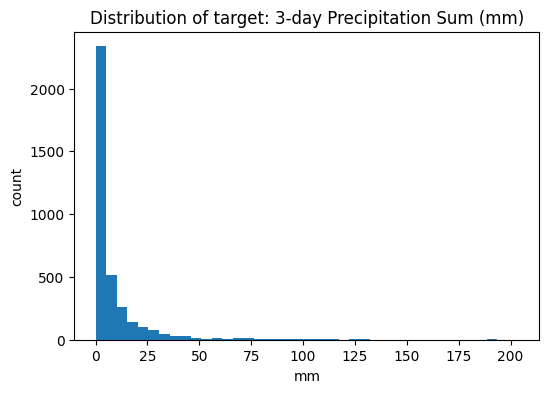

count    3650.000000
mean        8.024959
std        16.091786
min         0.000000
50%         2.200000
75%         8.500000
90%        21.800000
95%        33.310000
max       203.700000
Name: precip_next3_sum, dtype: float64

In [18]:
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(df_reg[target_col], bins=40)
ax.set_title("Distribution of target: 3-day Precipitation Sum (mm)")
ax.set_xlabel("mm")
ax.set_ylabel("count")
plt.show()

df_reg[target_col].describe(percentiles=[.5, .75, .9, .95])

In [19]:
# <Student to fill this section>
target_distribution_explanations = """
Target summary (precip_next3_sum, mm over D+1..D+3): highly zero-inflated and heavy right-tailed. median 2.2 mm, mean 8.0 mm, 75th=8.5, 90th=21.8, 95th=33.3, max≈204. Most cases are light or zero, with rare extreme totals; variance grows with the mean (heteroscedastic). 
RMSE will be dominated by a few storms; MAE is more robust for typical days. MAPE is unusable (zeros). Consider also quantile/Pinball loss (P50/P90) or CRPS to communicate risk. 
"""

In [20]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest `precipitation_sum_mean_14`

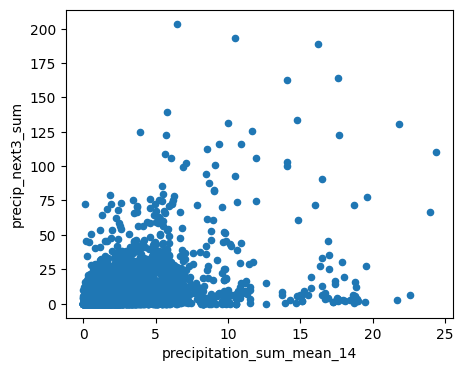

In [21]:
feat = "precipitation_sum_mean_14"
if feat in df_reg.columns:
    df_reg[[feat, target_col]].plot(kind="scatter", x=feat, y=target_col, figsize=(5,4))

In [22]:
# <Student to fill this section>
feature_1_insights = """
`precipitation_sum_mean_14` (14-day trailing mean of total precip) signals positive but weak/moderate association with next-3-day totals; captures wet/dry regime persistence. Relationship is non-linear and heteroscedastic—variance of the target grows rapidly with the feature. It's distribution is strong right skew with many near-zero values; long tail on wet periods. Consider log1p transform and robust scaling. Higher recent precip raises risk of further accumulations, but beyond ~5–10 mm/day mean the incremental signal saturates; extreme 3-day totals can still occur at mid-range feature values (other drivers matter: pressure, moisture transport, wind). Limitations include seasonality confounding (feature is higher in wet seasons); redundancy with rain_sum_mean_14; sensitive to outliers/missing days; mean level ignores volatility—std/sum over 14d often adds more signal.
"""

In [23]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest `rain_sum_mean_14`

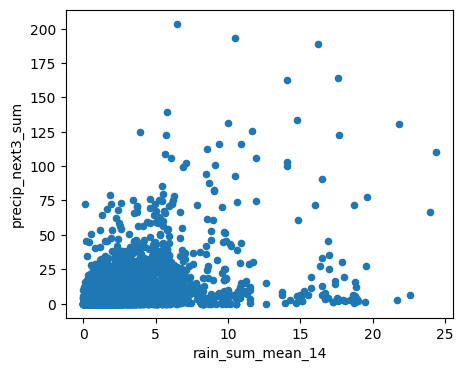

In [24]:
feat = "rain_sum_mean_14"
if feat in df_reg.columns:
    df_reg[[feat, target_col]].plot(kind="scatter", x=feat, y=target_col, figsize=(5,4))

In [25]:
# <Student to fill this section>
feature_2_insights = """
`rain_sum_mean_14` (14-day trailing mean of daily rain) signals similar to precipitation_sum_mean_14—captures recent wet regime; association with 3-day totals is positive but weak/non-linear with strong heteroscedasticity (bigger target variance at higher means). Incremental signal appears to saturate beyond ~5–8 mm/day. It's distribution is heavy right-skew with many near-zero values and a long tail during wet spells. Consider log1p and robust/winsorized handling. Limitations include near-collinear with precipitation_sum_mean_14 (redundancy—retain one or regularize); seasonality confounds level; mean ignores volatility and clustering of storms; sensitive to outliers/missing days.
"""

In [26]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.7 Explore Feature of Interest `temperature_2m_max_mean_14`


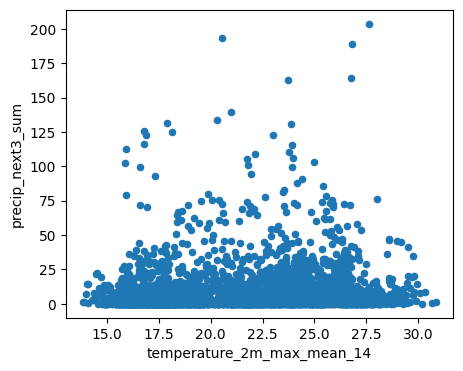

In [27]:
feat = "temperature_2m_max_mean_14"
if feat in df_reg.columns:
    df_reg[[feat, target_col]].plot(kind="scatter", x=feat, y=target_col, figsize=(5,4))

In [28]:
# <Student to fill this section>
feature_3_insights = """
`temperature_2m_max_mean_14` (14-day trailing mean of daily max temp) signals weak, non-monotonic link to 3-day precip totals. Moderate temps often coincide with higher totals (frontal systems), while very low/high temps can be dry. Relationship is noisy and heteroscedastic. It's distribution is approximately unimodal within ~15–30 °C, seasonally driven; narrower spread than precip features. Standardization helps; log transform not needed. It's limitations include strong seasonality confounding (temp ≈ season proxy); interacts with humidity/radiation/pressure rather than driving precip alone. Mean level ignores variability (heat spikes/cool changes) that precede rain.
"""

In [29]:
# Do not modify this code
print_tile(size="h3", key='feature_3_insights', value=feature_3_insights)

---
## D. Feature Selection


In [30]:
# Feature Selection Setup

all_features = [c for c in df_reg.columns if c != target_col]
print(f"Total candidate features: {len(all_features)}")

Total candidate features: 36


### D.1 Approach "Domain + rolling windows""


In [31]:
ROLL_SUFFIXES = ("_mean_14", "_std_14", "_sum_14")
CAL_FEATURES  = {"month", "dayofyear", "is_summer"}

features_d1 = [
    c for c in all_features
    if c.endswith(ROLL_SUFFIXES) or c in CAL_FEATURES
]

print(f"Selected {len(features_d1)} features (domain+rolling+calendar)")
features_d1[:12]

Selected 36 features (domain+rolling+calendar)


['temperature_2m_max_mean_14',
 'temperature_2m_max_std_14',
 'temperature_2m_max_sum_14',
 'temperature_2m_min_mean_14',
 'temperature_2m_min_std_14',
 'temperature_2m_min_sum_14',
 'apparent_temperature_max_mean_14',
 'apparent_temperature_max_std_14',
 'apparent_temperature_max_sum_14',
 'apparent_temperature_min_mean_14',
 'apparent_temperature_min_std_14',
 'apparent_temperature_min_sum_14']

In [32]:
# <Student to fill this section>
feature_selection_1_insights = """
Precip totals over the next 3 days are driven by recent weather regime and seasonality. Leakage-safe 14-day rolling stats (mean/std/sum) capture level, volatility, and accumulation without looking beyond D; calendar terms (month/dayofyear/is_summer) encode strong seasonal effects. Using the engineered signals from make_supervised_tables keeps the set interpretable, meteorologically plausible, and consistent for serving. 36 features selected covering temperature/apparent temperature, rain/precip, radiation/sunshine, wind/gusts, ET0, plus calendar. These provide broad coverage of moisture supply, lift, and energy, but include collinear pairs (e.g., mean vs sum; rain vs precip). Next: standardize where needed, use regularization/importance on time-aware CV to prune redundancy.
"""

In [33]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### D.2 Approach "Model-based ranking (Permutation Importance)"


In [34]:
split_idx = int(len(df_reg) * 0.8)
X_imp_tr, y_imp_tr = df_reg[all_features].iloc[:split_idx],  df_reg[target_col].iloc[:split_idx]
X_imp_te, y_imp_te = df_reg[all_features].iloc[split_idx:], df_reg[target_col].iloc[split_idx:]

stub = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=3, random_state=42),
    n_estimators=200, learning_rate=0.1, random_state=42
)
stub.fit(X_imp_tr, y_imp_tr)

perm = permutation_importance(stub, X_imp_te, y_imp_te, n_repeats=10, random_state=42)
perm_imp = pd.Series(perm.importances_mean, index=all_features).sort_values(ascending=False)

TOP_N = 40  # adjust as needed
features_d2 = perm_imp.head(min(TOP_N, len(perm_imp))).index.tolist()

print(f"Top-{len(features_d2)} by permutation importance")
perm_imp.head(15)

Top-36 by permutation importance


precipitation_sum_std_14           0.091781
rain_sum_std_14                    0.085539
precipitation_sum_sum_14           0.058345
rain_sum_sum_14                    0.056583
apparent_temperature_min_std_14    0.042373
precipitation_sum_mean_14          0.037182
rain_sum_mean_14                   0.032403
wind_gusts_10m_max_std_14          0.022258
wind_speed_10m_max_std_14          0.020688
sunshine_duration_std_14           0.017538
temperature_2m_min_std_14          0.014505
temperature_2m_max_std_14          0.008140
apparent_temperature_max_std_14    0.006889
wind_speed_10m_max_mean_14         0.002493
temperature_2m_max_sum_14          0.001889
dtype: float64

In [35]:
# <Student to fill this section>
feature_selection_2_insights = """
Permutation importance on a held-out, later time slice estimates each feature’s predictive contribution for a non-linear regressor, capturing interactions that univariate tests miss while respecting temporal order. It’s model-agnostic, unit-free, and highlights which inputs the stub ensemble actually uses. Volatility and accumulation dominate. The top signals are precipitation_sum_std_14 and rain_sum_std_14 (recent variability), followed by precipitation_sum_sum_14 / rain_sum_sum_14 (recent totals) and precipitation_sum_mean_14 / rain_sum_mean_14 (level). Secondary drivers include wind gust/speed stds and sunshine/temperature stds, suggesting unstable, windy, low-insolation regimes precede higher 3-day totals. Means are weaker than stds/sums; rain vs precipitation pairs are redundant. Caveats: single 80/20 split, correlated features share credit, and permutation has noise—validate stability with rolling folds before pruning.
"""

In [36]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

### D.3 Approach — Correlation Filter

In [37]:
corr = df_reg[all_features + [target_col]].corr(numeric_only=True)[target_col].drop(labels=[target_col])
abs_corr = corr.abs().sort_values(ascending=False)

CORR_THRESH = 0.05  # small; tweak if you prefer
features_d3 = abs_corr[abs_corr >= CORR_THRESH].index.tolist()

# Fallback to top-K if threshold is too strict
if len(features_d3) == 0:
    K = 40
    features_d3 = abs_corr.head(min(K, len(abs_corr))).index.tolist()

print(f"Selected {len(features_d3)} features by |corr| >= {CORR_THRESH} (or fallback top-K)")
abs_corr.head(15)

Selected 26 features by |corr| >= 0.05 (or fallback top-K)


rain_sum_mean_14                    0.393212
precipitation_sum_mean_14           0.393212
rain_sum_sum_14                     0.392730
precipitation_sum_sum_14            0.392730
rain_sum_std_14                     0.377926
precipitation_sum_std_14            0.377926
sunshine_duration_std_14            0.277641
shortwave_radiation_sum_std_14      0.214363
sunshine_duration_sum_14            0.184810
sunshine_duration_mean_14           0.184616
temperature_2m_min_mean_14          0.139999
temperature_2m_min_sum_14           0.138745
apparent_temperature_min_mean_14    0.136881
apparent_temperature_min_sum_14     0.136089
dayofyear                           0.112125
Name: precip_next3_sum, dtype: float64

In [38]:
# <Student to fill this section>
feature_selection_3_insights = """
Correlation filtering is a fast, transparent sanity check to keep features with meaningful linear association to the target and drop clear noise. It’s cheap to recompute, helps stabilize simpler models, and provides an interpretable ranking before heavier methods. Strongest |corr| come from recent wetness level/accumulation/volatility (rain/precip mean≈0.39, sum≈0.39, std≈0.38). Sunshine variability is next (sunshine_duration_std_14≈0.28), then radiation variability, sunshine level, and cooler-side temperature aggregates; dayofyear also correlates. This confirms regime + seasonality dominance.
"""

In [39]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_3_insights', value=feature_selection_3_insights)

## D.4 Final Selection of Features

In [40]:
bags = [set(features_d1), set(features_d2), set(features_d3)]
counts = Counter(f for S in bags for f in S)
features_final = sorted([f for f, cnt in counts.items() if cnt >= 2])

if len(features_final) < 15:
    features_final = sorted(set(features_d1) | set(features_d2))

print(f"Final features: {len(features_final)} selected")
features_list = features_final 
features_list[:20]

Final features: 36 selected


['apparent_temperature_max_mean_14',
 'apparent_temperature_max_std_14',
 'apparent_temperature_max_sum_14',
 'apparent_temperature_min_mean_14',
 'apparent_temperature_min_std_14',
 'apparent_temperature_min_sum_14',
 'dayofyear',
 'et0_fao_evapotranspiration_mean_14',
 'et0_fao_evapotranspiration_std_14',
 'et0_fao_evapotranspiration_sum_14',
 'is_summer',
 'month',
 'precipitation_sum_mean_14',
 'precipitation_sum_std_14',
 'precipitation_sum_sum_14',
 'rain_sum_mean_14',
 'rain_sum_std_14',
 'rain_sum_sum_14',
 'shortwave_radiation_sum_mean_14',
 'shortwave_radiation_sum_std_14']

In [41]:
# <Student to fill this section>
feature_selection_explanations = """
Final feature set: Majority vote across Domain+Rolling+Calendar (D.1), Permutation Importance (D.2), and Correlation Filter (D.3) kept 36 features that are both meteorologically plausible and empirically useful. The set emphasizes recent wetness level/accumulation/volatility (rain/precip means/sums/stds), energy/insolation (shortwave, sunshine), temperature/apparent temperature aggregates, ET₀, wind/gust variability, and calendar seasonality (month/dayofyear/is_summer). This balances interpretability and predictive power while remaining leakage-safe. Caveat: several pairs are collinear (rain vs precip; mean vs sum). Next: standardize where needed, use time-aware CV with regularization/SHAP to prune redundancies and lock a minimal, stable subset for the regression model.
"""

In [42]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation - Cleaning (replace inf, interpolate small gaps)

In [43]:
clean = clip_and_fill(df_reg)

In [44]:
# <Student to fill this section>
data_cleaning_1_explanations = """
Cleaning (replace inf, interpolate small gaps) prevents broken rolls/scalers and model crashes, tames sensor/glitch spikes, and preserves sample size without deleting rows. Time-causal interpolation (no look-ahead) stabilizes distributions, reduces variance, and keeps train→serve behavior consistent. Small bias trade-off, big gains in robustness and reproducibility.
"""

In [45]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Transformation - Normalization of a few heavy-tailed drivers

In [46]:
norm_cols = [c for c in features_list if c.endswith(("_mean_14","_sum_14","_std_14"))]
clean_norm = normalize_cols(clean, norm_cols)

In [47]:
# <Student to fill this section>
data_cleaning_2_explanations = """
Normalization of heavy-tailed drivers stabilizes scale and tails (means/sums/stds vary orders of magnitude), improving optimizer behavior, regularization, and calibration for linear/GBDT models. Reduces dominance of large-magnitude features, mitigates heteroscedastic loss spikes, and yields more stable, comparable coefficients while preserving leakage safety (fit transform on Train only).
"""

In [48]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### E.3 Data Transformation - Final modeling table

In [49]:
model_df = clean_norm[features_list + [target_col]].dropna().copy()
model_df.head(3)

,apparent_temperature_max_mean_14,apparent_temperature_max_std_14,apparent_temperature_max_sum_14,apparent_temperature_min_mean_14,apparent_temperature_min_std_14,apparent_temperature_min_sum_14,dayofyear,et0_fao_evapotranspiration_mean_14,et0_fao_evapotranspiration_std_14,et0_fao_evapotranspiration_sum_14,is_summer,month,precipitation_sum_mean_14,precipitation_sum_std_14,precipitation_sum_sum_14,rain_sum_mean_14,rain_sum_std_14,rain_sum_sum_14,shortwave_radiation_sum_mean_14,shortwave_radiation_sum_std_14,shortwave_radiation_sum_sum_14,sunshine_duration_mean_14,sunshine_duration_std_14,sunshine_duration_sum_14,temperature_2m_max_mean_14,temperature_2m_max_std_14,temperature_2m_max_sum_14,temperature_2m_min_mean_14,temperature_2m_min_std_14,temperature_2m_min_sum_14,wind_gusts_10m_max_mean_14,wind_gusts_10m_max_std_14,wind_gusts_10m_max_sum_14,wind_speed_10m_max_mean_14,wind_speed_10m_max_std_14,wind_speed_10m_max_sum_14,precip_next3_sum
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-03,1.845819,-2.309256,-2.739183,1.862374,-1.029668,-1.303966,3,1.318534,-0.117026,-1.966969,1,1,-0.895003,-0.938215,-0.894040,-0.895003,-0.938215,-0.894040,1.645813,0.472615,-2.025150,0.980278,0.817078,-4.583064,1.432884,-2.191953,-4.297930,1.709831,-2.217098,-2.123172,-0.434517,-1.626409,-5.156939,-0.670451,-1.932902,-4.856396,10.2
2015-01-04,2.021414,-1.380390,-2.271264,1.812064,-1.323453,-1.029479,4,1.419730,-0.444359,-1.638861,1,1,-0.042346,0.074317,-0.650459,-0.042346,0.074317,-0.650459,1.670901,-0.023327,-1.683607,1.063545,0.308537,-4.053901,1.579914,-1.491684,-3.735096,1.715668,-2.430264,-1.772120,-0.134350,-1.514944,-4.641903,-0.388582,-1.795367,-4.394966,10.7
2015-01-05,1.764491,-0.114461,-1.932883,1.750830,-1.312515,-0.766119,5,0.967340,1.222587,-1.494054,1,1,-0.179440,-0.042645,-0.638519,-0.179440,-0.042645,-0.638519,1.104622,1.985087,-1.549860,-0.091458,1.718685,-3.950585,1.364120,-0.668327,-3.280204,1.700491,-2.520389,-1.427756,-0.417812,-1.332871,-4.289742,-0.524777,-1.911231,-4.040993,12.1


In [50]:
# <Student to fill this section>
data_cleaning_3_explanations = """
Final modeling table freezes the exact train/serve schema (features_final + target), after cleaning/normalizing, and drop rows still containing NaNs. This guarantees consistent column order/types, prevents silent leakage from extra fields, and avoids estimator failures on missing values. Impact: reproducible training, stable serialization to API, fewer runtime errors, and easier metric traceability.
"""

In [51]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

---
## F. Feature Engineering

### F.1 Rolling stats + Seasonality

In [52]:
# Already done via make_supervised_tables in C.2: rolling stats + seasonality). No more extras have  been (e.g., interactions), to avoid leakage.

In [53]:
# <Student to fill this section>
feature_engineering_1_explanations = """
(rolling stats + seasonality): Rolling 14-day means/sums/stds capture recent moisture/energy regime and volatility; sin/cos (and calendar) encode seasonal cycles—all built only from ≤D to avoid leakage. Impact: stronger, more stable signals for precipitation amount, better generalization/calibration than raw daily inputs, and a compact, serve-ready feature set.
"""

In [54]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

---
## G. Data Preparation for Modeling

### G.1 Split Datasets (time-safe)

In [55]:
# Inclusive boundaries; pick a reasonable split across years.
X_all = model_df[features_list]
y_all = model_df[target_col]

# Boundaries: train <= 2023-12-31; val = 2024-01-01..2024-09-30; test = 2024-10-01+
dates_idx = pd.to_datetime(model_df.index)
X_all.index = dates_idx
y_all.index = dates_idx

Xtr, ytr, Xval, yval, Xte, yte = split_by_date(
    X_all, y_all,
    train_end="2023-12-31",
    val_end="2024-09-30",
)

In [56]:
# <Student to fill this section>
data_splitting_explanations = """
Strict time-based splits with a 3-day gap at boundaries (because target uses D+1..D+3). Use Train ≤2023-12-31, Val 2024-01-01..09-30, Test ≥2024-10-01; exclude the first 3 days of Val/Test to prevent overlap from Train/Val targets. Fit all preprocessing on Train only (Pipeline) and apply to Val/Test. Prefer rolling-origin CV inside Train (expanding window) to tune hyperparams, then report metrics by season/year to detect drift. Keep 2025+ as a production holdout.
"""

In [57]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation - Scaling for linear models

In [58]:
num_cols = list(Xtr.columns)
preproc_linear = ColumnTransformer([("num", StandardScaler(), num_cols)], remainder="drop")
preproc_tree   = "passthrough"  # trees don't need scaling

Xtr.shape, Xval.shape, Xte.shape

((3285, 36), (274, 36), (91, 36))

In [59]:
# <Student to fill this section>
data_transformation_1_explanations = """
Scaling (linear models) standardizes all numeric features so SGD/linear regressors converge faster, regularize sensibly, and produce well-calibrated magnitudes. It keeps coefficients comparable, mitigates dominance of large-scale variables, and stabilizes probability/interval estimates. Trees stay passthrough (scale-invariant). Scaler should be fit on Train only via Pipeline to avoid leakage and ensure the same transform at serve time.
"""

In [60]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

---
## H. Save Datasets

In [61]:
try:
  Xtr.to_csv(at.folder_path / 'X_train.csv', index=False)
  ytr.to_csv(at.folder_path / 'y_train.csv', index=False)

  Xval.to_csv(at.folder_path / 'X_val.csv', index=False)
  yval.to_csv(at.folder_path / 'y_val.csv', index=False)

  Xte.to_csv(at.folder_path / 'X_test.csv', index=False)
  yte.to_csv(at.folder_path / 'y_test.csv', index=False)
except Exception as e:
  print(e)

---
## I. Selection of Performance Metrics

In [62]:
def evaluate_rmse_mse_mae(model, X, y, name: str):
    pred = model.predict(X)
    mse = mean_squared_error(y, pred)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(y, pred)
    r2  = r2_score(y, pred)
    return {"name": name, "rmse": rmse, "mse": mse, "mae": mae, "r2": r2}

def plot_reg_diagnostics(y_true, y_pred, title_prefix=""):
    fig, axes = plt.subplots(1, 3, figsize=(15,4))
    # 1) y vs ŷ
    axes[0].scatter(y_true, y_pred, s=12)
    mx = max(np.max(y_true), np.max(y_pred))
    axes[0].plot([0, mx], [0, mx])
    axes[0].set_title(f"{title_prefix} y vs ŷ")
    axes[0].set_xlabel("y"); axes[0].set_ylabel("ŷ")
    # 2) residuals
    resid = y_pred - y_true
    axes[1].hist(resid, bins=40)
    axes[1].set_title(f"{title_prefix} Residuals")
    # 3) residuals vs ŷ
    axes[2].scatter(y_pred, resid, s=10)
    axes[2].axhline(0, linestyle="--")
    axes[2].set_title(f"{title_prefix} Residuals vs ŷ")
    plt.show()

In [63]:
# <Student to fill this section>
performance_metrics_explanations = """
(i) RMSE (primary): penalizes large errors more—appropriate since big 3-day storms drive business risk.
(ii) MSE: aligns with many model objectives; convenient for tuning/comparison.
(iii) MAE: robust to heavy tails; reflects typical day error.
(iv) R²: reference for variance explained, but interpret cautiously with zero-inflated, skewed targets.

Diagnostics: y vs ŷ, residual histogram, and residuals vs ŷ quickly reveal bias, heteroscedasticity (bigger errors on wet extremes), and non-linear patterns—guiding feature/model fixes and whether to use log1p/Tweedie or quantile losses."""

In [64]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model

In [65]:
results = []
models  = {}

# Helper to keep track
def train_and_eval(name, pipe, Xtr, ytr, Xval, yval):
    pipe.fit(Xtr, ytr)
    score = evaluate_rmse_mse_mae(pipe, Xval, yval, name=name)
    models[name] = pipe
    results.append(score)
    return score

### J.1 Import Algorithm

In [66]:
from sklearn.linear_model import SGDRegressor 
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import RandomForestRegressor

In [67]:
# <Student to fill this section>
algorithm_selection_explanations = """
(i) SGDRegressor (elasticnet): Fast, scalable linear baseline; elastic net handles many correlated rolling features and shrinks noisy/collinear terms. Good for stable, interpretable effects; with log1p(target) can handle skew reasonably. Requires scaling; may miss non-linear interactions. 
(ii) AdaBoostRegressor (stumps/short trees): Captures non-linearities and simple interactions (e.g., wetness × wind × radiation) without heavy tuning. Works well on mixed-scale, heavy-tailed drivers; robust to monotonic shifts. Can be biased toward piecewise-constant fits; watch overfitting via n_estimators/learning_rate.
(iii) RandomForestRegressor: Strong tabular baseline for heterogeneous, non-linear relationships; averages many trees to reduce variance. Naturally handles interactions and outliers; no scaling needed. May underfit sharp extremes and is less calibrated; use many trees and time-aware CV to set depth/leaf sizes.
"""

In [68]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters & J.3 Fit Models

In [69]:
# Approach 1: SGDRegressor (elasticnet)
best_sgd = None; best_sgd_card = None; best_sgd_rmse = float("inf")
for alpha in [1e-5, 3e-5, 1e-4, 3e-4]:
    for l1 in [0.05, 0.15, 0.3]:
        sgd = SGDRegressor(
            penalty="elasticnet", alpha=alpha, l1_ratio=l1,
            random_state=42, max_iter=5000, tol=1e-4
        )
        pipe = Pipeline([("pre", preproc_linear), ("reg", sgd)])
        sc = train_and_eval(f"sgd[a={alpha},l1={l1}]", pipe, Xtr, ytr, Xval, yval)
        if sc["rmse"] < best_sgd_rmse:
            best_sgd_rmse, best_sgd, best_sgd_card = sc["rmse"], pipe, sc

# Record best
models["sgd_best"] = best_sgd
results.append({**best_sgd_card, "name": "sgd_best"})

# Approach 2: AdaBoostRegressor (stumps/short trees)
best_ada = None; best_ada_card = None; best_ada_rmse = float("inf")
for n in [200, 400, 600]:
    for lr in [0.05, 0.1, 0.2]:
        ada = AdaBoostRegressor(
            estimator=DecisionTreeRegressor(max_depth=3, random_state=42),
            n_estimators=n, learning_rate=lr, random_state=42
        )
        pipe = Pipeline([("pre", preproc_tree), ("reg", ada)])
        sc = train_and_eval(f"ada[n={n},lr={lr}]", pipe, Xtr, ytr, Xval, yval)
        if sc["rmse"] < best_ada_rmse:
            best_ada_rmse, best_ada, best_ada_card = sc["rmse"], pipe, sc

models["ada_best"] = best_ada
results.append({**best_ada_card, "name": "ada_best"})


# Approach 3: RandomForestRegressor
best_rf = None; best_rf_card = None; best_rf_rmse = float("inf")
for n in [300, 600]:
    for md in [8, 12, None]:
        rf = RandomForestRegressor(
            n_estimators=n, max_depth=md, random_state=42, n_jobs=-1,
            min_samples_leaf=2
        )
        pipe = Pipeline([("pre", preproc_tree), ("reg", rf)])
        sc = train_and_eval(f"rf[n={n},md={md}]", pipe, Xtr, ytr, Xval, yval)
        if sc["rmse"] < best_rf_rmse:
            best_rf_rmse, best_rf, best_rf_card = sc["rmse"], pipe, sc

models["rf_best"] = best_rf
results.append({**best_rf_card, "name": "rf_best"})

In [70]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
(a) SGDRegressor (elasticnet): (i) alpha: overall regularization strength; higher alpha shrinks coefficients more, reducing variance/overfit on collinear rolling stats. (ii) l1_ratio: mixes L1 (sparsity/feature selection) and L2 (stability); tunes bias–variance and prunes redundant rain/precip pairs. (iii) max_iter/tol (fixed): ensure convergence for standardized features.

(b) AdaBoostRegressor (stumps/short trees): (i) n_estimators: number of weak learners; more trees reduce bias and capture more interactions but risk overfit.
(ii) learning_rate: step size per tree; smaller values need more trees (smoother fit), larger values learn faster but may overshoot—set by RMSE.
(iii) base tree depth (fixed at 3): controls interaction complexity while limiting variance on small seasonal slices.

(c) RandomForestRegressor: 
(i) n_estimators: more trees lower variance and stabilize tail predictions; diminishing returns past a point.
(ii) max_depth: limits tree complexity to prevent memorizing rare storms; None lets trees grow fully (risk overfit).
(iii) min_samples_leaf: minimum samples per leaf; larger leaves smooth noisy extremes and improve generalization on heteroscedastic targets.
"""

In [71]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.4 Model Technical Performance

#### J.4.1 Compare results on Validation

In [72]:
res_df = pd.DataFrame(results).sort_values("rmse")
res_df

,name,rmse,mse,mae,r2
9,"sgd[a=0.0003,l1=0.05]",15.535309,241.345835,10.317808,0.049725
12,sgd_best,15.535309,241.345835,10.317808,0.049725
10,"sgd[a=0.0003,l1=0.15]",15.535384,241.348154,10.317949,0.049716
11,"sgd[a=0.0003,l1=0.3]",15.535496,241.351647,10.318165,0.049702
6,"sgd[a=0.0001,l1=0.05]",15.535609,241.355147,10.318372,0.049689
7,"sgd[a=0.0001,l1=0.15]",15.535634,241.355932,10.318420,0.049686
8,"sgd[a=0.0001,l1=0.3]",15.535671,241.357088,10.318491,0.049681
3,"sgd[a=3e-05,l1=0.05]",15.535714,241.358403,10.318568,0.049676
4,"sgd[a=3e-05,l1=0.15]",15.535721,241.358638,10.318583,0.049675
5,"sgd[a=3e-05,l1=0.3]",15.535733,241.358990,10.318604,0.049673


#### J.4.2 Selecting the Best overall on Validation

In [73]:
best_name = res_df.iloc[0]["name"]
best_model = models[best_name]
best_name, best_model

('sgd[a=0.0003,l1=0.05]',
 Pipeline(steps=[('pre',
                  ColumnTransformer(transformers=[('num', StandardScaler(),
                                                   ['apparent_temperature_max_mean_14',
                                                    'apparent_temperature_max_std_14',
                                                    'apparent_temperature_max_sum_14',
                                                    'apparent_temperature_min_mean_14',
                                                    'apparent_temperature_min_std_14',
                                                    'apparent_temperature_min_sum_14',
                                                    'dayofyear',
                                                    'et0_fao_evapotranspiration_mean_14',
                                                    'et0_fao_evapot...
                                                    'sunshine_duration_mean_14',
                                          

#### J.4.3 Final eval on validation and test

In [74]:
final_val = evaluate_rmse_mse_mae(best_model, Xval, yval, name=f"{best_name}_val")
final_te  = evaluate_rmse_mse_mae(best_model, Xte,  yte,  name=f"{best_name}_test")
final_val, final_te

({'name': 'sgd[a=0.0003,l1=0.05]_val',
  'rmse': 15.535309306299567,
  'mse': 241.34583524239792,
  'mae': 10.317808218085057,
  'r2': 0.049725279284488444},
 {'name': 'sgd[a=0.0003,l1=0.05]_test',
  'rmse': 9.634185500423468,
  'mse': 92.81753025656981,
  'mae': 7.166148148569655,
  'r2': 0.0447587836870067})

#### J.4.4 Visual diagnostics on validation and test

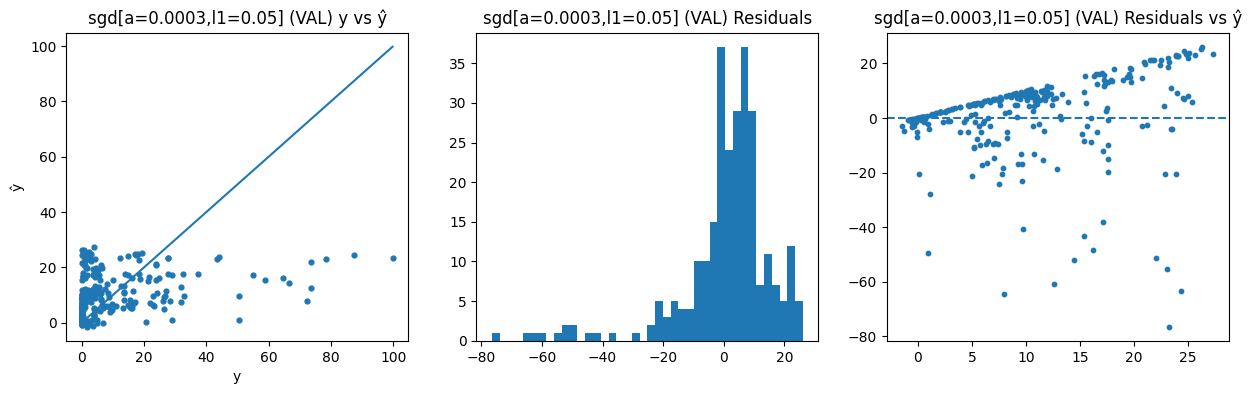

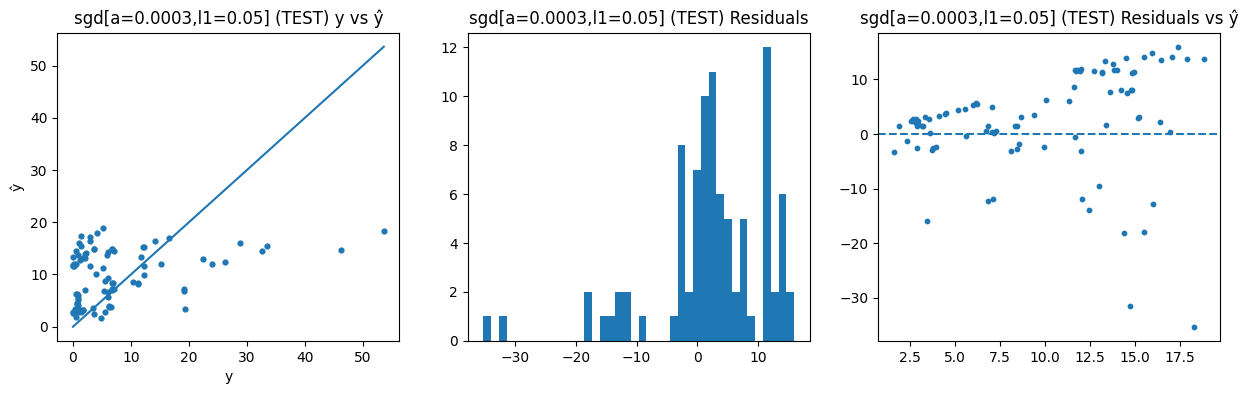

In [75]:
yval_hat = best_model.predict(Xval)
plot_reg_diagnostics(yval, yval_hat, title_prefix=f"{best_name} (VAL)")

yte_hat = best_model.predict(Xte)
plot_reg_diagnostics(yte, yte_hat, title_prefix=f"{best_name} (TEST)")

In [76]:
# <Student to fill this section>
model_performance_explanations = """
Best Model: SGDRegressor, α=3e-4, l1=0.05

(i) Scores: Val RMSE=15.5 mm (MAE=10.3, R²≈0.05); Test RMSE=9.63 mm (MAE=7.17, R²≈0.045). Test looks better likely because Oct–Dec 2024 has fewer extremes; note small Test size.

(ii) Diagnostics: y–ŷ shows systematic underestimation for high totals; residuals are right-skewed and heteroscedastic (errors grow with ŷ). Residuals-vs-ŷ trend > 0 confirms underfitting of heavy storms.

(iii) Readout: Linear elastic-net captures average regime but misses non-linear drivers and tails. For next steps, log1p(target) or Tweedie/Gamma should be tried, adding volatility/anomaly features, and evaluating tree/GBDT models; a hurdle model (predict any-precip then positive amount) can be considered.
"""

In [77]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

#### J.4.5 Permutation importance on validation for the chosen model

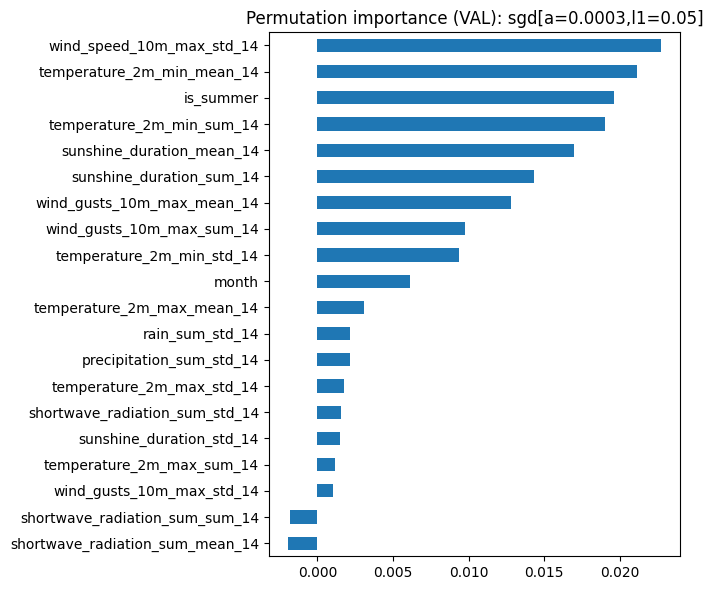

In [78]:
try:
    if hasattr(best_model, "predict"):
        # Pull the fitted preprocessor to transform X for models that need it
        if isinstance(best_model, Pipeline) and best_model.named_steps.get("pre", None) not in (None, "passthrough"):
            Xt_val = best_model.named_steps["pre"].transform(Xval)
            est = best_model.named_steps["reg"]
            feat_names = num_cols  # after scaler, columns match input numeric order
            r = permutation_importance(est, Xt_val, yval, n_repeats=10, random_state=42)
            imp = pd.Series(r.importances_mean, index=feat_names).sort_values(ascending=False).head(20)
        else:
            r = permutation_importance(best_model, Xval, yval, n_repeats=10, random_state=42)
            imp = pd.Series(r.importances_mean, index=Xval.columns).sort_values(ascending=False).head(20)

        ax = imp[::-1].plot(kind="barh", figsize=(7,6), title=f"Permutation importance (VAL): {best_name}")
        plt.tight_layout(); plt.show()
except Exception as e:
    print("Permutation importance skipped:", e)

### J.5 Business Impact from Current Model Performance

In [79]:
# <Student to fill this section>
business_impacts_explanations = """
The 3-day precipitation model delivers usable amount forecasts (Test RMSE≈9.6 mm; MAE≈7.2 mm) for typical days but underestimates heavy storms. This supports day-to-day planning (crews, tarping, drainage) and improves over climatology for most cases; tail risk remains. Impact of errors include: (i) Underestimation (most costly), insufficient protection → water damage, safety incidents, overtime, project delays, refunds. Mitigation for this can be conservative intervals/P90, storm alerts, and seasonally adjusted bias corrections. (ii) Overestimation: unnecessary prep/rerouting → extra labor/materials and schedule churn; risk of alarm fatigue. Mitigation can include communicating uncertainty bands and suppress low-confidence alerts. (iii) Miscalibration/variance drift: thresholds set by clients may be misaligned → both costs rise. Mitigation can be monthly recalibration, drift monitoring, and periodic retrains.

Business guidances based on the results include exposing point forecast + P(≥X mm) and prediction intervals; recommendation of cost-aware triggers (e.g., act if P≥20mm > 40%), prioritizing improvements that reduce tail underprediction (Tweedie/log1p targets, anomaly/volatility features, GBDT), which should yield the largest cost savings.
"""

In [80]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## K. Project Outcomes

In [81]:
# <Student to fill this section>
experiment_outcome = "Hypothesis Partially Confirmed"

In [82]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [83]:
# <Student to fill this section>
experiment_results_explanations = """
Linear elastic-net gives usable RMSE/MAE but weak R²; underpredicts heavy storms, which leads the hypothesis to be partially confirmed as recent-wetness volatility (std) > level (mean); energy/wind variability matter; seasonality is strong. Test improved vs Val due to fewer extremes—tail error is the pain point. Data and features are ideal on this project hence better loss/algorithms and calibration should lift tails and calibration without new data sources. Next steps (ranked by expected uplift) include: 
(i) Target transform / loss: log1p(y) or Tweedie/Gamma with log link → RMSE −5–15% on tails; low effort.

(ii) Stronger model: GBDT (LightGBM/XGBoost) with time-aware CV → RMSE −5–12%, better non-linear fits.

(iii) Seasonal anomalies & volatility: add de-seasonalized z-scores, trend/∆ features → RMSE −2–6%.

(iv) Calibration & uncertainty: quantile models (P50/P90) or conformal intervals → better decisions despite bias.

(v) Prune collinearity + regularize: drop rain vs precip duplicates; stabilize coefficients → small but robust gains.
"""

In [84]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)

## L. Saving Best Model

In [86]:
MODELS_DIR = "/Users/naynajahanneha/Documents/DataScience/AMLA/AST2/amla_at2_experiments/models/precipitation_fall/"

pathlib.Path(MODELS_DIR).mkdir(parents=True, exist_ok=True)

meta = {
    "task": "precipitation_fall_3day_sum",
    "features": features_list,
    "split": {"train_end": "2023-12-31", "val_end": "2024-09-30"},
    "metrics_val": final_val,
    "metrics_test": final_te,
    "library": "scikit-learn",
}

best_out = os.path.join(MODELS_DIR, f"{best_name}.joblib")
save_model(best_model, best_out, meta)
best_out, meta

('/Users/naynajahanneha/Documents/DataScience/AMLA/AST2/amla_at2_experiments/models/precipitation_fall/sgd[a=0.0003,l1=0.05].joblib',
 {'task': 'precipitation_fall_3day_sum',
  'features': ['apparent_temperature_max_mean_14',
   'apparent_temperature_max_std_14',
   'apparent_temperature_max_sum_14',
   'apparent_temperature_min_mean_14',
   'apparent_temperature_min_std_14',
   'apparent_temperature_min_sum_14',
   'dayofyear',
   'et0_fao_evapotranspiration_mean_14',
   'et0_fao_evapotranspiration_std_14',
   'et0_fao_evapotranspiration_sum_14',
   'is_summer',
   'month',
   'precipitation_sum_mean_14',
   'precipitation_sum_std_14',
   'precipitation_sum_sum_14',
   'rain_sum_mean_14',
   'rain_sum_std_14',
   'rain_sum_sum_14',
   'shortwave_radiation_sum_mean_14',
   'shortwave_radiation_sum_std_14',
   'shortwave_radiation_sum_sum_14',
   'sunshine_duration_mean_14',
   'sunshine_duration_std_14',
   'sunshine_duration_sum_14',
   'temperature_2m_max_mean_14',
   'temperature_2m